In [1]:
import os
from typing import Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from pprint import pprint

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms
from torchinfo import summary

In [2]:
# Verify Numpy and Pandas libs installation
print("=== UTILS INFO ===")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

print('-'*60)

print("=== PYTORCH INFO ===")

torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Verify PyTorch installation and system configuration
print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

# Display CUDA availability for GPU acceleration
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set default device for tensor operations
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

=== UTILS INFO ===
Numpy Version: 2.0.2
Pandas Version: 2.3.3
------------------------------------------------------------
=== PYTORCH INFO ===
PyTorch Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
CUDA Available: True
CUDA Version: 12.8
Available GPU: Tesla T4
GPU Memory: 15.6 GB
Using device: cuda


In [3]:
# Importing data
IMAGES_DIR = "/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images/"
full_train_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

full_train_df.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9cd3df7acfbf4bb8a00466801469b08b.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
# Distinguishing image name column and label column
image_name = "id"
label_columns = full_train_df.columns[1:].tolist()

print("=== IMAGES PATH COLUMN ===")
print(image_name)
print('-'*60)
print("=== LABEL COLUMNS ===")
print(label_columns)
print('='*60)

=== IMAGES PATH COLUMN ===
id
------------------------------------------------------------
=== LABEL COLUMNS ===
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


In [5]:
# Converting One-Hot class to labels
full_train_df["label"] = full_train_df[label_columns].idxmax(axis=1)

le = LabelEncoder()
full_train_df["label_idx"] = le.fit_transform(full_train_df["label"])

train_df, val_df = train_test_split(
    full_train_df, 
    test_size=0.2, 
    random_state=42, 
    stratify=full_train_df['label']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
train_df.head()

Train: 40834 | Val: 10209


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding,label,label_idx
50221,01510f83fd2c4e389080467f7fcac71b.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Atelectasis,0
8660,f25448fa584e4b138726eb15b13534d7.png,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Consolidation,3
38691,26ef6e59a3d64263861861506c2ab237.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Mass,10
33375,7114ba198f554459b441c16c2e7088c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,No Finding,11
50276,9b341d5f74a24aefb02f67f9c8abc075.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,No Finding,11


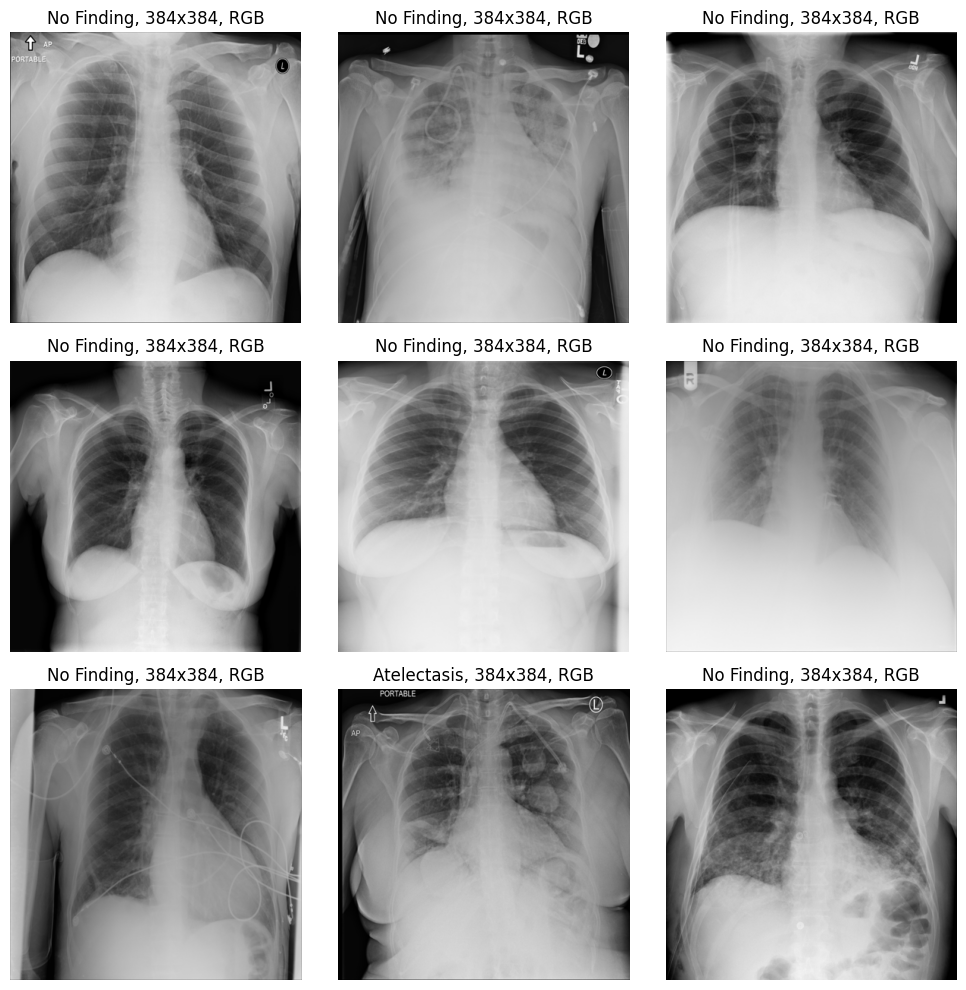

In [6]:
# Images visulaiztion

train_sample = train_df.sample(9)
plt.figure(figsize=(10, 10))

for i, (_, row) in enumerate(train_sample.iterrows()):
    image_path = os.path.join(IMAGES_DIR, row[image_name])
    img = Image.open(image_path)
    height, width = img.size

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"{row["label"]}, {height}x{width}, {img.mode}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Verifying class distribution

print("=== CLASS DISTRIBUTION ===")
for label in label_columns:
    print(f"{label}:")
    print(f"Full Train Data")
    print(f"    Count: {len(full_train_df[full_train_df[label] == 1])} | Ratio: {len(full_train_df[full_train_df[label] == 1]) / (full_train_df.shape[0])*100:.3f}%")
    print(f"Train Data")
    print(f"    Count: {len(train_df[train_df[label] == 1])} | Ratio: {len(train_df[train_df[label] == 1]) / (train_df.shape[0])*100:.3f}%")
    print(f"Val Data")
    print(f"    Count: {len(val_df[val_df[label] == 1])} | Ratio: {len(val_df[val_df[label] == 1]) / (val_df.shape[0])*100:.3f}%")
    print('-'*10)

print("=== AVAILABLE LABELS ===")
print(label_columns)

=== CLASS DISTRIBUTION ===
Atelectasis:
Full Train Data
    Count: 2351 | Ratio: 4.606%
Train Data
    Count: 1881 | Ratio: 4.606%
Val Data
    Count: 470 | Ratio: 4.604%
----------
Cardiomegaly:
Full Train Data
    Count: 600 | Ratio: 1.175%
Train Data
    Count: 480 | Ratio: 1.175%
Val Data
    Count: 120 | Ratio: 1.175%
----------
Consolidation:
Full Train Data
    Count: 651 | Ratio: 1.275%
Train Data
    Count: 521 | Ratio: 1.276%
Val Data
    Count: 130 | Ratio: 1.273%
----------
Edema:
Full Train Data
    Count: 326 | Ratio: 0.639%
Train Data
    Count: 261 | Ratio: 0.639%
Val Data
    Count: 65 | Ratio: 0.637%
----------
Effusion:
Full Train Data
    Count: 2156 | Ratio: 4.224%
Train Data
    Count: 1725 | Ratio: 4.224%
Val Data
    Count: 431 | Ratio: 4.222%
----------
Emphysema:
Full Train Data
    Count: 172 | Ratio: 0.337%
Train Data
    Count: 138 | Ratio: 0.338%
Val Data
    Count: 34 | Ratio: 0.333%
----------
Fibrosis:
Full Train Data
    Count: 389 | Ratio: 0.762%
Trai

In [8]:
def create_transform_pipeline():
    # Resnet mean and standard deviation
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

    return train_transform, test_transform

train_transform, test_transform = create_transform_pipeline()

print("=== DATA PREPROCESSION TRANSFORMATION PIPELINE ===")
print(f"Training Transformation: {len(train_transform.transforms)} operations.")
print(f"Testing Transformation: {len(test_transform.transforms)} operations.")
print('-'*20)
print("Training Pipeline:")
for i, transform in enumerate(train_transform.transforms, 1):
    print(f"    {i}. {transform}")
print('-'*20)
print("Testing Pipeline:")
for i, transform in enumerate(test_transform.transforms, 1):
    print(f"    {i}. {transform}")

=== DATA PREPROCESSION TRANSFORMATION PIPELINE ===
Training Transformation: 6 operations.
Testing Transformation: 3 operations.
--------------------
Training Pipeline:
    1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    2. RandomHorizontalFlip(p=0.5)
    3. RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    4. ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=None, hue=None)
    5. ToTensor()
    6. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
--------------------
Testing Pipeline:
    1. Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    2. ToTensor()
    3. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [9]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, img_dir, label_cols=label_columns, transform=None, is_test=False):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_cols = label_cols
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = os.path.join(self.img_dir, str(row['id']))
        image = Image.open(img_name)
        
        if self.transform:
            image = self.transform(image)     
        if self.is_test:
            return image
        
        label = torch.tensor(row['label_idx'], dtype=torch.long)
        return image, label

train_dataset = ImageDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset   = ImageDataset(val_df, IMAGES_DIR, transform=test_transform)
test_dataset  = ImageDataset(test_df, IMAGES_DIR, transform=test_transform, is_test=True)

print("=== DATASET AND DATALOADER SUMMARY ===")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Testing samples: {len(test_dataset)}")
print('-'*30)
print(f"Number of classes: {len(label_columns)}")
print(f"Class names: {label_columns}")

=== DATASET AND DATALOADER SUMMARY ===
Training samples: 40834
Validation samples: 10209
Testing samples: 17015
------------------------------
Number of classes: 20
Class names: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']


In [10]:
# Creating a Custom Sample for dataloading
train_labels      = train_df["label_idx"].values
class_counts      = np.bincount(train_labels)
class_sample_w    = 1.0 / class_counts[train_labels]

sampler = WeightedRandomSampler(
    weights=class_sample_w,
    num_samples=len(class_sample_w),
    replacement=True
)

print("=== Sampler ===")
print(f"Sampler ready — {len(class_sample_w)} sample weights")
print(f"Class counts: {class_counts}")

=== Sampler ===
Sampler ready — 40834 sample weights
Class counts: [ 1881    73   480   521   261  1725   138   311    30  4165   999 27263
  1221   486     4   128    35   891    19   203]


In [11]:
# Data Loading

BATCH_SIZE = 32

# Create the Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("=== Batch Dataloader ===")
print(f"Batch size: {train_loader.batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

=== Batch Dataloader ===
Batch size: 32
Training batches per epoch: 1277
Validation batches: 320
Testing batches: 532


In [12]:
# Defining DenseNet121 Model

def build_densenet121(num_classes: int, dropout: float = 0.3) -> nn.Module:
    model = torchvision.models.densenet121(weights=torchvision.models.DenseNet121_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=dropout),
        nn.Linear(512, num_classes),
    )
    return model

model = build_densenet121(len(label_columns)).to(device)

summary(model=model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 158MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 20]                   --
├─Sequential: 1-1                        [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         (128)
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 56, 56]           (45,440)
│    │    └─_DenseLayer: 3-2             [1, 32, 56, 56]           (49,600)
│    │    └─_DenseLayer: 3-3             [1, 32, 56, 56]           (53,760)
│    │    └─_DenseLayer: 3-4             [1, 32, 56, 56]           (57,920)
│    │    └─_DenseLayer: 3-5             [1, 32, 56, 56]           (62,080)
│    │    └─_DenseLayer: 3-6             [1, 32

In [13]:
# Ddefing custom FocalLoss

class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha  # class weights tensor [C]
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = self.alpha[targets] * (1 - pt) ** self.gamma * ce
        return loss.mean()

In [14]:
# Class weights from training labels

train_labels = train_df['label_idx'].values  # single integer labels

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

alpha_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = FocalLoss(alpha=alpha_tensor, gamma=2.0)
print("Criterion ready. Class weight range:", f"{class_weights.min():.1f} – {class_weights.max():.1f}")

Criterion ready. Class weight range: 0.1 – 510.4


In [15]:
# Calculating Score according to the Competition

def competition_score(logits: torch.Tensor, targets: torch.Tensor) -> float:
    probs       = torch.softmax(logits, dim=1).cpu().numpy()
    tgts        = targets.cpu().numpy()
    preds       = probs.argmax(axis=1)  # one predicted class per sample
    num_classes = logits.shape[1]

    class_scores = []
    for c in range(num_classes):
        N = (tgts == c).sum()
        if N == 0:
            continue
        TP = ((preds == c) & (tgts == c)).sum()
        FP = ((preds == c) & (tgts != c)).sum()
        FN = ((preds != c) & (tgts == c)).sum()
        class_scores.append((TP - FP - 5 * FN) / N)

    return float(np.mean(class_scores)) if class_scores else 0.0

In [16]:
# Train Step
def train_step(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Val Step
def val_step(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []

    with torch.inference_mode():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            total_loss += criterion(logits, labels).item()
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits)  # [N, C]
    all_labels = torch.cat(all_labels)  # [N]
    comp_score = competition_score(all_logits, all_labels)

    return total_loss / len(loader), comp_score

In [17]:
# Custom phase logic for Optimizer

def get_optimizer(model, phase):
    if phase == 1:
        return torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
    elif phase == 2:
        return torch.optim.Adam([
            {"params": model.features.denseblock4.parameters(), "lr": 1e-4},
            {"params": model.classifier.parameters(),           "lr": 1e-3},
        ])
    else:
        return torch.optim.Adam([
            {"params": model.features.denseblock3.parameters(), "lr": 5e-5},
            {"params": model.features.denseblock4.parameters(), "lr": 1e-4},
            {"params": model.classifier.parameters(),           "lr": 1e-3},
        ])

In [18]:
# Training Loop

PHASE_EPOCHS = {1: 5, 2: 5, 3: 10}   # 20 epochs total
TOTAL_EPOCHS = sum(PHASE_EPOCHS.values())

results = {"train_loss": [], "val_loss": [], "val_score": []}
best_score = -999
thresholds = [0.5] * len(label_columns)

epoch_global = 0
for phase, n_ep in PHASE_EPOCHS.items():
    print(f"\n=== Phase {phase} — unfreezing layers, {n_ep} epochs ===")
    
    # Unfreeze progressively
    if phase == 2:
        for p in model.features.denseblock4.parameters():
            p.requires_grad = True
    elif phase == 3:
        for p in model.features.denseblock3.parameters():
            p.requires_grad = True
    
    optimizer = get_optimizer(model, phase)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_ep)
    
    for ep in range(n_ep):
        epoch_global += 1
        t_loss              = train_step(model, train_loader, criterion, optimizer, device)
        v_loss, comp_score  = val_step(model, val_loader, criterion, device)
        scheduler.step()
        
        results["train_loss"].append(t_loss)
        results["val_loss"].append(v_loss)
        results["val_score"].append(comp_score)
        
        flag = " ★" if comp_score > best_score else ""
        if comp_score > best_score:
            best_score = comp_score
            torch.save(model.state_dict(), "best_model.pt")
        
        print(f"  Ep {epoch_global:>2}/{TOTAL_EPOCHS} | "
              f"train_loss={t_loss:.4f} | val_loss={v_loss:.4f} | "
              f"comp_score={comp_score:.4f}{flag}")

print(f"\nBest competition score: {best_score:.4f}")


=== Phase 1 — unfreezing layers, 5 epochs ===
  Ep  1/20 | train_loss=27.3087 | val_loss=3.4309 | comp_score=-135.4710 ★
  Ep  2/20 | train_loss=21.7705 | val_loss=3.2487 | comp_score=-124.7407 ★
  Ep  3/20 | train_loss=19.5270 | val_loss=3.2594 | comp_score=-112.2534 ★
  Ep  4/20 | train_loss=17.3004 | val_loss=3.2264 | comp_score=-68.2538 ★
  Ep  5/20 | train_loss=16.4339 | val_loss=3.2416 | comp_score=-62.3343 ★

=== Phase 2 — unfreezing layers, 5 epochs ===
  Ep  6/20 | train_loss=11.7179 | val_loss=3.1005 | comp_score=-32.7793 ★
  Ep  7/20 | train_loss=8.1166 | val_loss=3.5192 | comp_score=-23.2462 ★
  Ep  8/20 | train_loss=6.5356 | val_loss=3.3993 | comp_score=-21.1112 ★
  Ep  9/20 | train_loss=5.6343 | val_loss=3.4034 | comp_score=-18.8910 ★
  Ep 10/20 | train_loss=5.2237 | val_loss=3.5436 | comp_score=-17.9621 ★

=== Phase 3 — unfreezing layers, 10 epochs ===
  Ep 11/20 | train_loss=6.0982 | val_loss=3.7105 | comp_score=-23.9736
  Ep 12/20 | train_loss=8.1777 | val_loss=3.9334

In [19]:
# Final val score with tuned thresholds
model.load_state_dict(torch.load("best_model.pt"))
_, final_score = val_step(model, val_loader, criterion, device)
print(f"Final competition score (best checkpoint): {final_score:.4f}")

Final competition score (best checkpoint): -12.8334


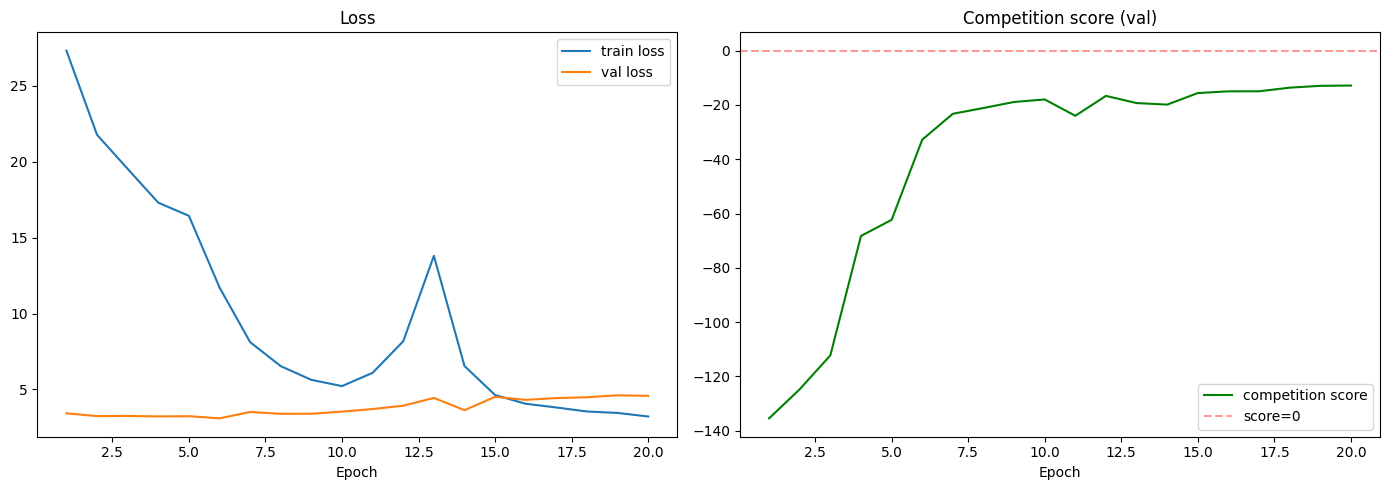

In [20]:
def plot_training(results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(results["train_loss"]) + 1)
    
    ax1.plot(epochs, results["train_loss"], label="train loss")
    ax1.plot(epochs, results["val_loss"],   label="val loss")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    
    ax2.plot(epochs, results["val_score"], label="competition score", color="green")
    ax2.axhline(0, color="red", linestyle="--", alpha=0.4, label="score=0")
    ax2.set_title("Competition score (val)"); ax2.set_xlabel("Epoch"); ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_training(results)

In [21]:
def get_classification_report(model, loader, device, le):
    model.eval()
    all_preds, all_labels = [], []

    with torch.inference_mode():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(classification_report(
        all_labels, all_preds,
        target_names=le.classes_,
        zero_division=0
    ))

get_classification_report(model, val_loader, device, le)

                            precision    recall  f1-score   support

               Atelectasis       0.00      0.00      0.00       470
Calcification of the Aorta       0.00      0.00      0.00        18
              Cardiomegaly       0.04      0.47      0.08       120
             Consolidation       0.03      0.21      0.06       130
                     Edema       0.03      0.71      0.05        65
                  Effusion       0.00      0.00      0.00       431
                 Emphysema       0.02      0.44      0.04        34
                  Fibrosis       0.02      0.60      0.03        78
                    Hernia       0.03      0.14      0.05         7
              Infiltration       0.00      0.00      0.00      1041
                      Mass       0.00      0.00      0.00       250
                No Finding       0.00      0.00      0.00      6816
                    Nodule       0.00      0.00      0.00       306
        Pleural_Thickening       0.01      0.02

In [22]:
# Submission

SUBMISSION_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum',
    'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta',
    'Calcification of the Aorta', 'No Finding'
]

def generate_submission(model, loader, label_cols, test_df, path="submission.csv"):
    model.eval()
    all_probs = []

    with torch.inference_mode():
        for imgs in tqdm(loader, desc="Predicting"):
            imgs  = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1).cpu().numpy()
            all_probs.append(probs)

    probs_matrix = np.vstack(all_probs)       # [N, C]
    pred_indices = probs_matrix.argmax(axis=1) # one class per row

    # One-hot encode: place a single 1 at the predicted class column
    submission = pd.DataFrame(0, index=range(len(test_df)), columns=label_cols)
    for i, col_idx in enumerate(pred_indices):
        submission.iloc[i, col_idx] = 1

    submission.insert(0, "id", test_df["id"].values)
    submission = submission[["id"] + SUBMISSION_COLS]
    submission.to_csv(path, index=False)
    print(f"Saved {path} — shape: {submission.shape}")
    print(submission.head())

generate_submission(model, test_loader, label_columns, test_df)

Predicting:   0%|          | 0/532 [00:00<?, ?it/s]

Saved submission.csv — shape: (17015, 21)
                                     id  Atelectasis  Cardiomegaly  \
0  7b647fbfcc874a7084a4470fc150e267.png            0             0   
1  cc804b94d80c4a80a206298c307adfec.png            0             0   
2  1df09c3becd04de995244caae36ddf57.png            0             0   
3  044cac47cfdf4c8b90848c9e56c36bfa.png            0             0   
4  a873523c43664a049c5e8f26add7ecb2.png            0             0   

   Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  Infiltration  \
0              0      0         0          0         0       1             0   
1              0      0         0          0         0       0             0   
2              0      0         0          0         0       0             0   
3              0      0         0          0         0       1             0   
4              0      0         0          0         0       0             0   

   ...  Nodule  Pleural_Thickening  Pneumonia  Pneumotho